In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import yaml
from pathlib import Path
import sys
sys.path.append('../')

from src.visualization.plotting import plot_training_history, plot_classification_analysis

In [2]:
try:
    with open('../config/params.yml', 'r') as f:
        params = yaml.safe_load(f)
except FileNotFoundError:
    print("\nERROR: config/params.yml no encontrado.")
    params = None
except Exception as e:
    print(f"\nERROR al leer config/params.yml: {e}")
    params = None

if not params:
    print("\nNo se pudo cargar la configuración.")
    sys.exit(1)

exp_params = params.get('experiment', {})
exp_name = exp_params.get('name', 'default_experiment')
exp_base_dir = Path(exp_params.get('base_dir', '../experiments'))
experiment_dir = exp_base_dir / exp_name

print(f"\nCargando configuración para el experimento: {exp_name}")
print(f"Directorio del experimento: {experiment_dir.resolve()}")

dp_params = params.get('data_pipeline', {})
artifact_params = params.get('model_artifacts', {})
optuna_params = params.get('optuna_search', {})

manifests_subdir = experiment_dir / dp_params.get('manifests_subdir', 'results/tables')
plots_dir = experiment_dir / artifact_params.get('plots_subdir', 'results/plots')

plots_dir.mkdir(parents=True, exist_ok=True)

final_metrics_path = manifests_subdir / artifact_params.get('final_metrics_name', 'lstm_final_metrics.json')
training_history_path = manifests_subdir / artifact_params.get('training_history_name', 'lstm_training_history.json')
test_predictions_path = manifests_subdir / artifact_params.get('test_predictions_name', 'lstm_test_predictions.json')
optuna_results_csv = manifests_subdir / optuna_params.get('results_csv_name', 'optuna_lstm_trials.csv')

with open(final_metrics_path, 'r') as f:
    final_metrics = json.load(f)

with open(training_history_path, 'r') as f:
    training_history = json.load(f)

with open(test_predictions_path, 'r') as f:
    test_predictions = json.load(f)

optuna_df = pd.read_csv(optuna_results_csv)

print(f"Cargados artefactos del experimento: {exp_params.get('name')}")
print(f"Mejor AUC de validación: {final_metrics['best_validation_auc']:.4f}")


Cargando configuración para el experimento: exp_13
Directorio del experimento: D:\Dataset\experiments\exp_13
Cargados artefactos del experimento: exp_13
Mejor AUC de validación: 0.8790


Gráfico de historial guardado en: D:\Dataset\experiments\exp_13\results\plots\1_training_history.png


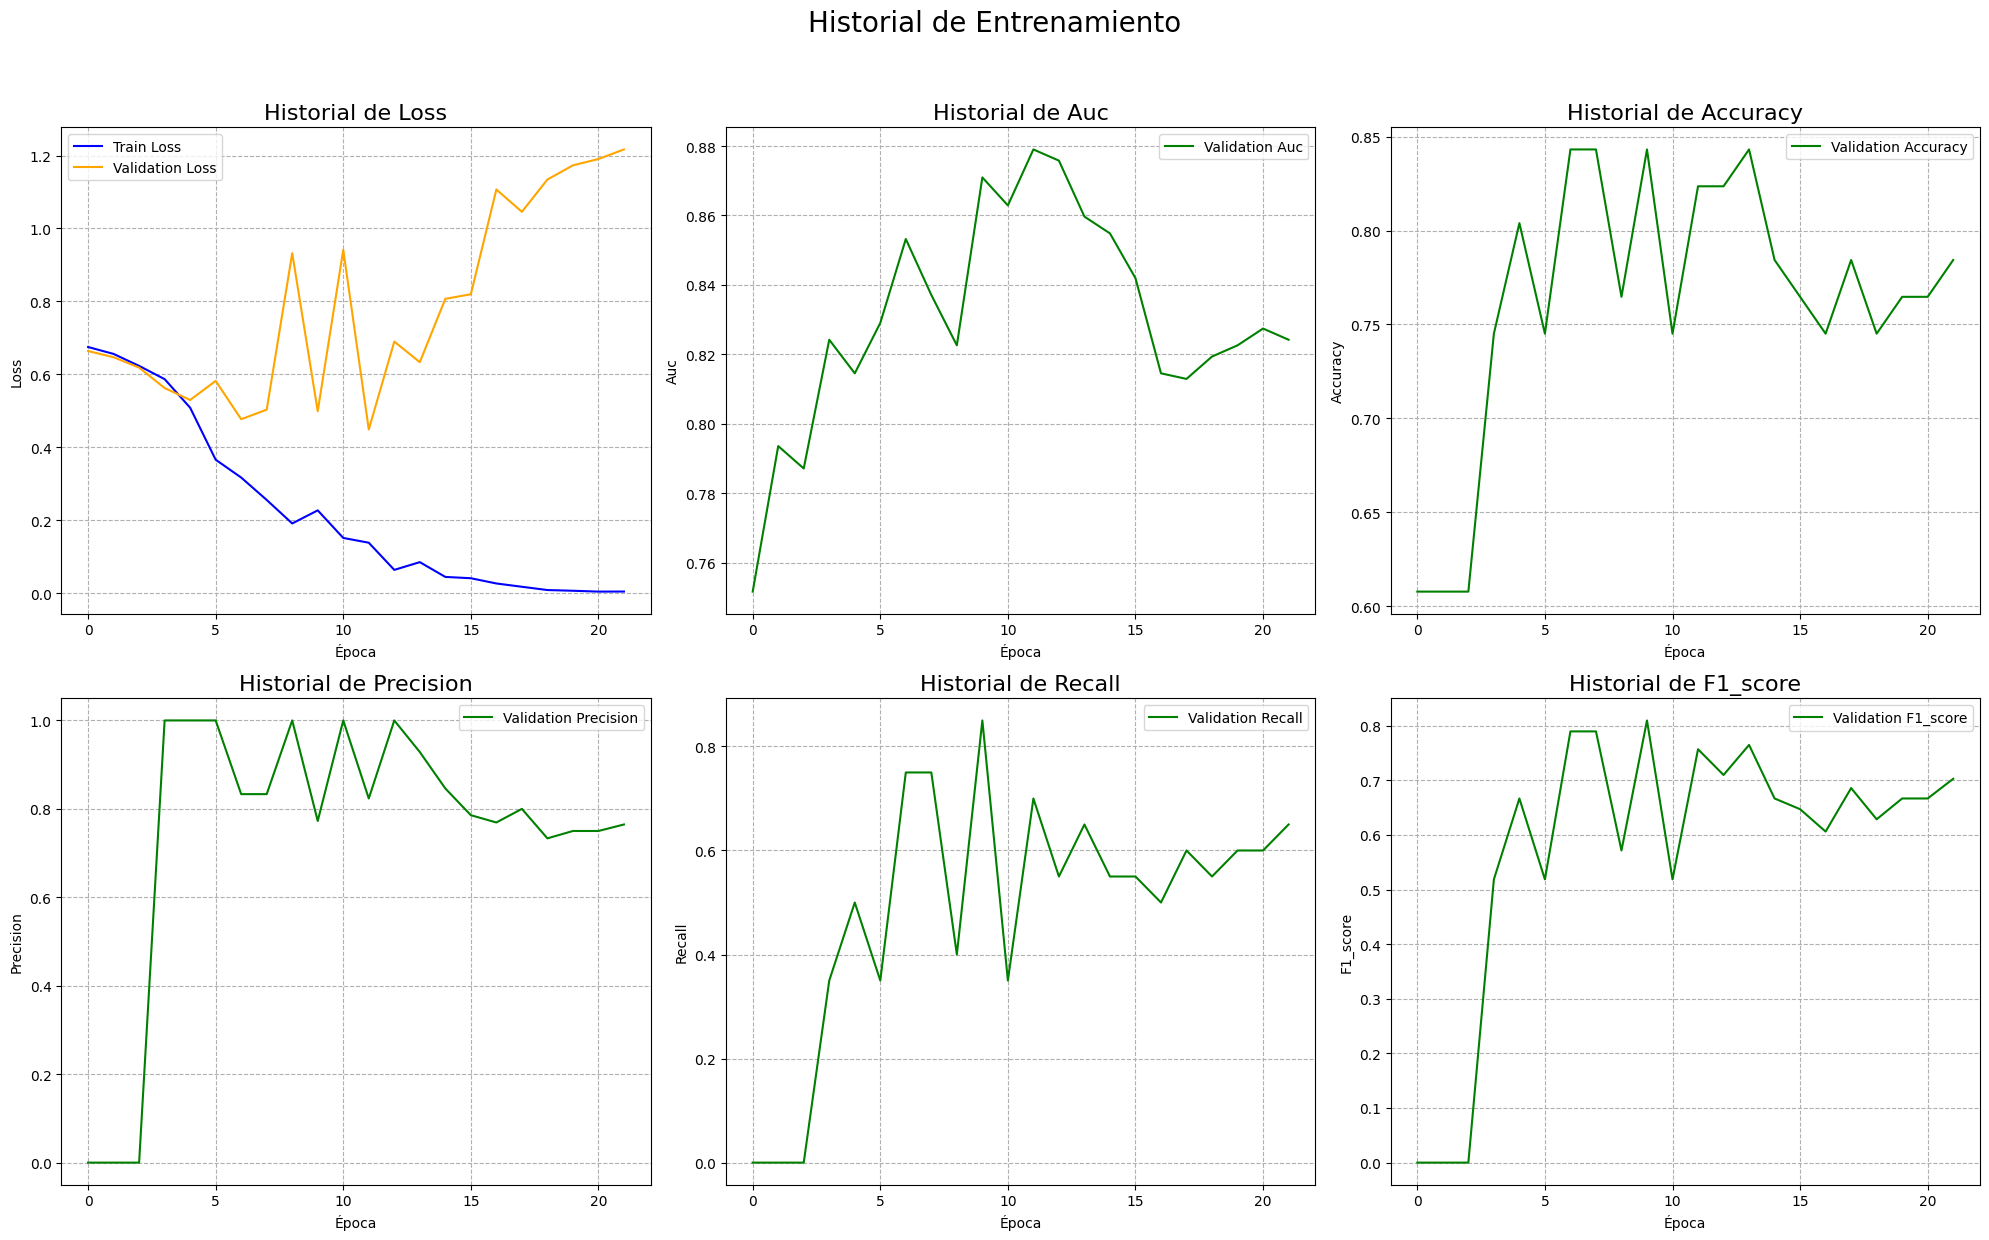

In [3]:
history_plot_path = plots_dir / '1_training_history.png'
plot_training_history(training_history, save_path=history_plot_path)

In [4]:
test_metrics = final_metrics.get('test_metrics', {})
metrics_df = pd.DataFrame.from_dict(test_metrics, orient='index', columns=['Valor'])
metrics_df.index.name = 'Métrica'
display(metrics_df.style.format({'Valor': '{:.4f}'}))

,Valor
Métrica,
loss,0.5991
accuracy,0.7812
precision,0.6897
recall,0.8000
f1_score,0.7407
auc,0.8605


Gráfico de análisis de clasificación guardado en: D:\Dataset\experiments\exp_13\results\plots\2_classification_analysis.png


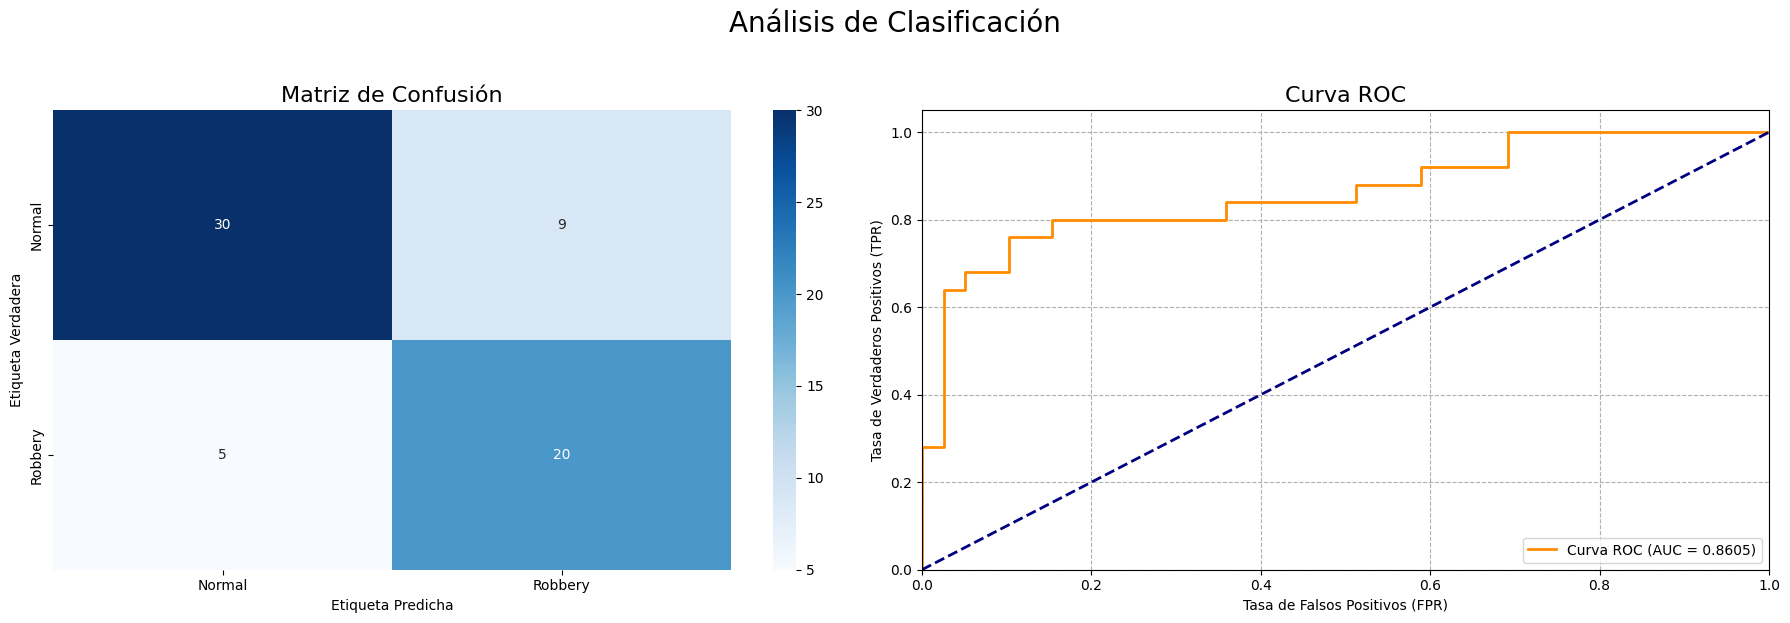

In [5]:
y_true = test_predictions["labels"]
y_pred = test_predictions["preds"]
y_probs = test_predictions["probs"]

class_names = ['Normal', 'Robbery']

analysis_plot_path = plots_dir / '2_classification_analysis.png'

plot_classification_analysis(y_true, y_pred, y_probs, class_names, save_path=analysis_plot_path)

In [6]:
top_trials = optuna_df.sort_values(by='value', ascending=False).head(5)
display(top_trials[['number', 'value', 'params_hidden_size', 'params_num_layers', 'params_lr', 'params_batch_size', 'params_dropout_fc']])

top_trials_path = plots_dir / '3_top5_optuna_trials.csv'
top_trials.to_csv(top_trials_path, index=False)
print(f"Top 5 trials de Optuna guardados en: {top_trials_path.resolve()}")

,number,value,params_hidden_size,params_num_layers,params_lr,params_batch_size,params_dropout_fc
60,60,0.721981,128,3,0.000855,16,0.229249
48,48,0.712812,128,2,0.000730,16,0.217111
39,39,0.711595,64,1,0.000712,16,0.499719
25,25,0.678687,64,2,0.000685,16,0.326913
29,29,0.675636,96,2,0.001302,16,0.276591


Top 5 trials de Optuna guardados en: D:\Dataset\experiments\exp_13\results\plots\3_top5_optuna_trials.csv
